In [ ]:
import torch
print(torch.__version__)

2.11.0+cpu


In [ ]:
x = torch.tensor([4.8])
print(x)

tensor([4.8000])


In [ ]:
x = torch.tensor([4.8], requires_grad=True)
print(x)

tensor([4.8000], requires_grad=True)


In [ ]:

u = x ** 2
print(u)

tensor([23.0400], grad_fn=<PowBackward0>)


In [ ]:
du_dx = torch.autograd.grad(u, x)[0]
print(du_dx)

tensor([9.6000])


In [ ]:
x = torch.tensor([3.0], requires_grad=True)
u = x ** 2

du_dx = torch.autograd.grad(u, x, create_graph=True)[0]
d2u_dx2 = torch.autograd.grad(du_dx, x)[0]

print("First derivative:", du_dx)
print("Second derivative:", d2u_dx2)

First derivative: tensor([6.], grad_fn=<MulBackward0>)
Second derivative: tensor([2.])


In [ ]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(1, 32)
        self.layer2 = nn.Linear(32, 32)
        self.layer3 = nn.Linear(32, 1)

    def forward(self, x):
        u = torch.tanh(self.layer1(x))
        u = torch.tanh(self.layer2(u))
        u = self.layer3(u)
        return u

network = MLP()
print(network)

MLP(
  (layer1): Linear(in_features=1, out_features=32, bias=True)
  (layer2): Linear(in_features=32, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=1, bias=True)
)


In [ ]:
x = torch.tensor([[3.0]], requires_grad=True)
u = network(x)
print("Input x:", x)
print("Output u:", u)

Input x: tensor([[3.]], requires_grad=True)
Output u: tensor([[-0.1587]], grad_fn=<AddmmBackward0>)


In [ ]:
x = torch.tensor([[3.0]], requires_grad=True)
u = network(x)

du_dx = torch.autograd.grad(u, x, create_graph=True)[0]
d2u_dx2 = torch.autograd.grad(du_dx, x)[0]

print("u:", u)
print("du/dx:", du_dx)
print("d2u/dx2:", d2u_dx2)

u: tensor([[-0.1587]], grad_fn=<AddmmBackward0>)
du/dx: tensor([[0.0333]], grad_fn=<TBackward0>)
d2u/dx2: tensor([[-0.0022]])


In [ ]:
import torch.optim as optim

# Create 100 random points between -π and π
x_train = torch.linspace(-3.14, 3.14, 100).reshape(-1, 1)
u_train = torch.sin(x_train)

# Optimizer - this adjusts the weights during training
optimizer = optim.Adam(network.parameters(), lr=0.01)

# Training loop
for epoch in range(3000):
    optimizer.zero_grad()

    u_pred = network(x_train)
    loss = torch.mean((u_pred - u_train) ** 2)

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 0.548055
Epoch 500, Loss: 0.000006
Epoch 1000, Loss: 0.000003
Epoch 1500, Loss: 0.000003
Epoch 2000, Loss: 0.000004
Epoch 2500, Loss: 0.000003


In [ ]:
x_test = torch.linspace(-3.14, 3.14, 100).reshape(-1, 1).requires_grad_(True)

u_pred = network(x_test)

du_dx = torch.autograd.grad(u_pred.sum(), x_test, create_graph=True)[0]
d2u_dx2 = torch.autograd.grad(du_dx.sum(), x_test)[0]

# Analytical values
u_true = torch.sin(x_test)
du_true = torch.cos(x_test)
d2u_true = -torch.sin(x_test)

print("Max error in u:", torch.max(torch.abs(u_pred - u_true)).item())
print("Max error in du/dx:", torch.max(torch.abs(du_dx - du_true)).item())
print("Max error in d2u/dx2:", torch.max(torch.abs(d2u_dx2 - d2u_true)).item())

Max error in u: 0.005403353367000818
Max error in du/dx: 0.07415193319320679
Max error in d2u/dx2: 0.3479047119617462


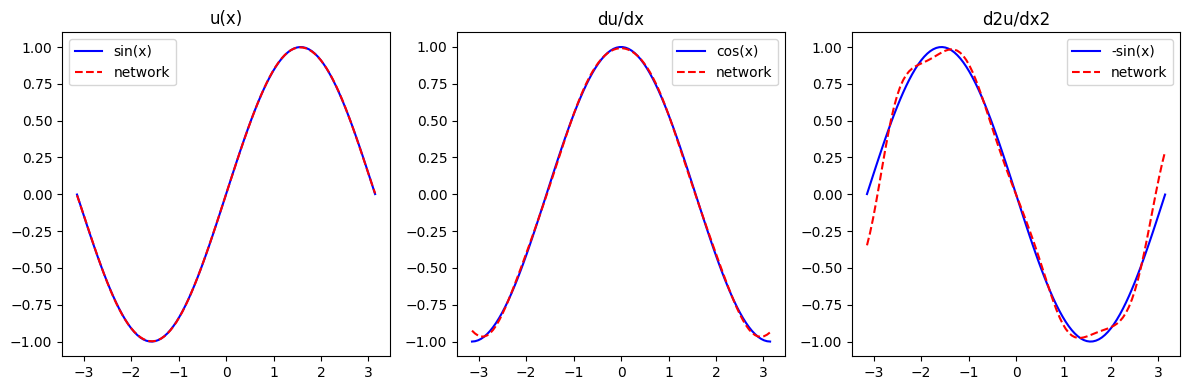

In [ ]:
# @title
import matplotlib.pyplot as plt

x_np = x_test.detach().numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(x_np, u_true.detach().numpy(), label='sin(x)', color='blue')
plt.plot(x_np, u_pred.detach().numpy(), label='network', color='red', linestyle='--')
plt.title('u(x)')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(x_np, du_true.detach().numpy(), label='cos(x)', color='blue')
plt.plot(x_np, du_dx.detach().numpy(), label='network', color='red', linestyle='--')
plt.title('du/dx')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(x_np, d2u_true.detach().numpy(), label='-sin(x)', color='blue')
plt.plot(x_np, d2u_dx2.detach().numpy(), label='network', color='red', linestyle='--')
plt.title('d2u/dx2')
plt.legend()

plt.tight_layout()
plt.show()